In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import feature_scoring
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
from sklearn import tree
from pprint import pprint 
import graphviz
import sklearn
import dtreeviz

from collections import Counter
from collections import deque
import os
import sys
# sys.path.insert(0, '..')

from aws_archspace import AWS_Microservices
from archspace import show_pairplot, show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D, show_configuration_space2D

In [2]:
my_space = AWS_Microservices()
my_space.create_model('aws_microservices')

# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_null70.csv')
# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_null70_sampling50_nosingleton.csv')
# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_null70_sampling50_singleton.csv')
experiments_df, outcomes_df = my_space.load_results('./aws_dataset_null70_sampling10_singleton.csv')
# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_null70_sampling10_nosingleton.csv')
# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_null70_sampling10_singleton_latency.csv')
# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_null70_sampling10_singleton_availability.csv')
# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_latency_null70_sampling10_singleton.csv')
# experiments_df, outcomes_df = my_space.load_results('./aws_dataset_availability_null70_sampling10_singleton.csv')

print(len(my_space.get_configurations()), "configurations")
print("Configurations:", my_space.get_configurations())

(516, 70)
QAS: ['latency', 'availability']
4 configurations
Configurations: ['high_traffic', 'low_traffic', 'temporal1', 'temporal2']


In [3]:
experiments_df

,scenario,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#petlistadoptions_AWS::ECS::Fargate,latency#lambda_step_priceLessThan55,latency#petlistadoptions_client,latency#lambda_step_priceLessThan55_AWS::Lambda,latency#Servi-searc.us-west-2.elb.amazonaws.com_remote,latency#lambda_step_priceLessThan55_AWS::Lambda::Function,latency#https://sqs.us-west-2.amazonaws.com/Services-sqspetadoption_AWS::SQS::Queue,latency#PetSearch_AWS::ECS::Fargate,...,availability#PGSQL Query_remote,availability#payforadoption_AWS::ECS::Container,availability#SSM_AWS::SSM,availability#AWS::StepFunctions::StateMachine,availability#Evidently_AWS::Evidently,availability#PetSearch_client,availability#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,availability#servi-lista.us-west-2.elb.amazonaws.com_remote,model,policy
0,0,0.016328,0.025139,2.332743,0.000045,2.446667,0.009132,2.448980,0.009092,0.007527,...,100.0,100.000000,100.0,57.142857,100.0,100.0,100.0,100.000000,aws_microservices,low_traffic
1,0,0.016975,0.024265,1.385058,0.000045,2.169250,0.005974,2.037210,0.011010,0.006632,...,100.0,100.000000,100.0,63.636364,100.0,100.0,100.0,100.000000,aws_microservices,low_traffic
2,0,0.016167,0.022177,1.046356,0.000049,1.195667,0.009736,1.201802,0.007535,0.005942,...,100.0,100.000000,100.0,83.333333,100.0,100.0,100.0,100.000000,aws_microservices,low_traffic
3,0,0.015604,0.022318,1.902514,0.000045,3.924750,0.015342,2.827195,0.009505,0.005723,...,100.0,100.000000,100.0,33.333333,100.0,100.0,100.0,100.000000,aws_microservices,low_traffic
4,0,0.015967,0.024490,0.260862,0.000047,3.603667,0.010843,3.021519,0.007413,0.006293,...,100.0,100.000000,100.0,41.666667,100.0,100.0,100.0,100.000000,aws_microservices,low_traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,4,0.015836,0.021719,1.767520,0.000044,5.567000,0.009843,3.003479,0.010138,0.006625,...,100.0,91.304348,100.0,54.545455,100.0,100.0,100.0,100.000000,aws_microservices,temporal2
512,5,0.017083,0.022442,1.903841,0.000048,3.171182,0.008327,2.383726,0.010260,0.005877,...,100.0,100.000000,100.0,36.842105,100.0,100.0,100.0,92.105263,aws_microservices,temporal2
513,6,0.020624,0.020218,0.260862,0.000043,6.011000,0.010163,3.003573,0.011914,0.007053,...,100.0,80.000000,100.0,30.000000,100.0,100.0,100.0,100.000000,aws_microservices,temporal2
514,7,0.016802,0.023801,2.275924,0.000044,2.577571,0.010586,2.397561,0.009547,0.006615,...,100.0,100.000000,100.0,50.000000,100.0,100.0,100.0,100.000000,aws_microservices,temporal2


In [4]:
experiments_df.describe()

,scenario,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#petlistadoptions_AWS::ECS::Fargate,latency#lambda_step_priceLessThan55,latency#petlistadoptions_client,latency#lambda_step_priceLessThan55_AWS::Lambda,latency#Servi-searc.us-west-2.elb.amazonaws.com_remote,latency#lambda_step_priceLessThan55_AWS::Lambda::Function,latency#https://sqs.us-west-2.amazonaws.com/Services-sqspetadoption_AWS::SQS::Queue,latency#PetSearch_AWS::ECS::Fargate,...,availability#servi-petsi.us-west-2.elb.amazonaws.com_remote,availability#lambda_step_readDDB,availability#PGSQL Query_remote,availability#payforadoption_AWS::ECS::Container,availability#SSM_AWS::SSM,availability#AWS::StepFunctions::StateMachine,availability#Evidently_AWS::Evidently,availability#PetSearch_client,availability#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,availability#servi-lista.us-west-2.elb.amazonaws.com_remote
count,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,...,516.000000,516.0,516.0,516.000000,516.0,516.000000,516.000000,516.000000,516.0,516.000000
mean,1.500000,0.016377,0.033729,1.489247,0.000046,2.456346,0.017005,2.026326,0.009308,0.011422,...,11.434109,100.0,100.0,99.555468,100.0,51.205599,88.565891,99.797137,100.0,99.914741
std,4.755988,0.001227,0.118901,0.788262,0.000006,1.229401,0.088391,0.801929,0.002855,0.047187,...,31.853389,0.0,0.0,3.093906,0.0,20.638921,31.853389,1.520602,0.0,0.795865
min,0.000000,0.014410,0.017075,0.260862,0.000038,0.420556,0.005974,0.430967,0.006419,0.004921,...,0.000000,100.0,100.0,67.592593,100.0,0.000000,0.000000,79.245283,100.0,87.500000
25%,0.000000,0.015577,0.020488,0.774106,0.000043,1.719281,0.008188,1.623471,0.008306,0.005811,...,0.000000,100.0,100.0,100.000000,100.0,37.500000,100.000000,100.000000,100.0,100.000000
50%,0.000000,0.016089,0.022198,1.652000,0.000044,2.403000,0.008639,2.231759,0.008918,0.006048,...,0.000000,100.0,100.0,100.000000,100.0,53.589744,100.000000,100.000000,100.0,100.000000
75%,0.000000,0.016803,0.023533,2.271444,0.000049,3.179087,0.009547,2.538205,0.009800,0.006425,...,0.000000,100.0,100.0,100.000000,100.0,66.666667,100.000000,100.000000,100.0,100.000000
max,26.000000,0.020980,2.053450,2.979426,0.000137,6.130000,1.586565,3.038385,0.051649,0.782842,...,100.000000,100.0,100.0,100.000000,100.0,100.000000,100.000000,100.000000,100.0,100.000000


In [5]:
# experiments_df[['availability#PetSite', 'latency#PetSite']]

In [6]:
set(experiments_df['policy'])

{'high_traffic', 'low_traffic', 'temporal1', 'temporal2'}

In [7]:
color_key = {'high_traffic': 'red',
             'low_traffic': 'blue',
            'temporal1': 'yellow',
             'temporal2': 'green'}
# embeddings_df = show_configuration_space2D(experiments_df, color_key=color_key, alpha=0.7)

In [8]:
outcomes_df

,latency,availability
0,0.093621,100.000000
1,0.090363,99.802761
2,0.087036,100.000000
3,0.090945,100.000000
4,0.097556,100.000000
...,...,...
511,0.115486,98.076923
512,0.109179,97.588832
513,0.104806,95.823096
514,0.291723,99.857550


In [9]:
outcomes_df.describe()

,latency,availability
count,516.000000,516.000000
mean,0.110246,99.682073
std,0.066289,1.043830
min,0.085174,91.232877
25%,0.096171,99.794871
50%,0.099072,100.000000
75%,0.102499,100.000000
max,1.017715,100.000000


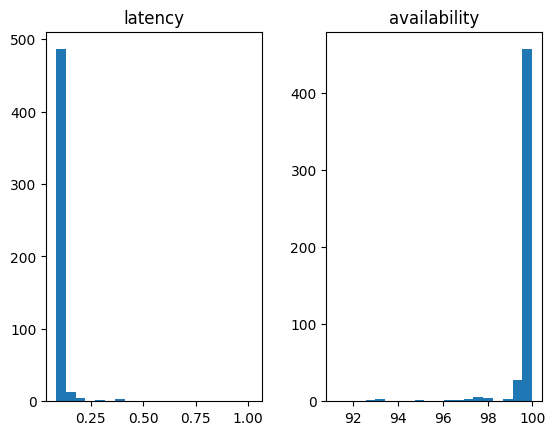

In [10]:
# outcomes
outcomes_df.hist(bins=20, grid=False)
plt.show()

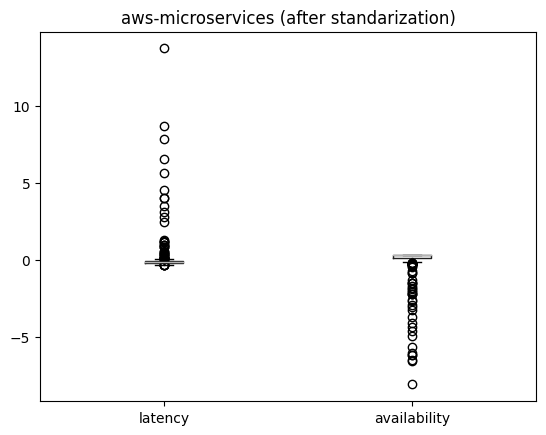

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('aws-microservices (after standarization)')
plt.show()

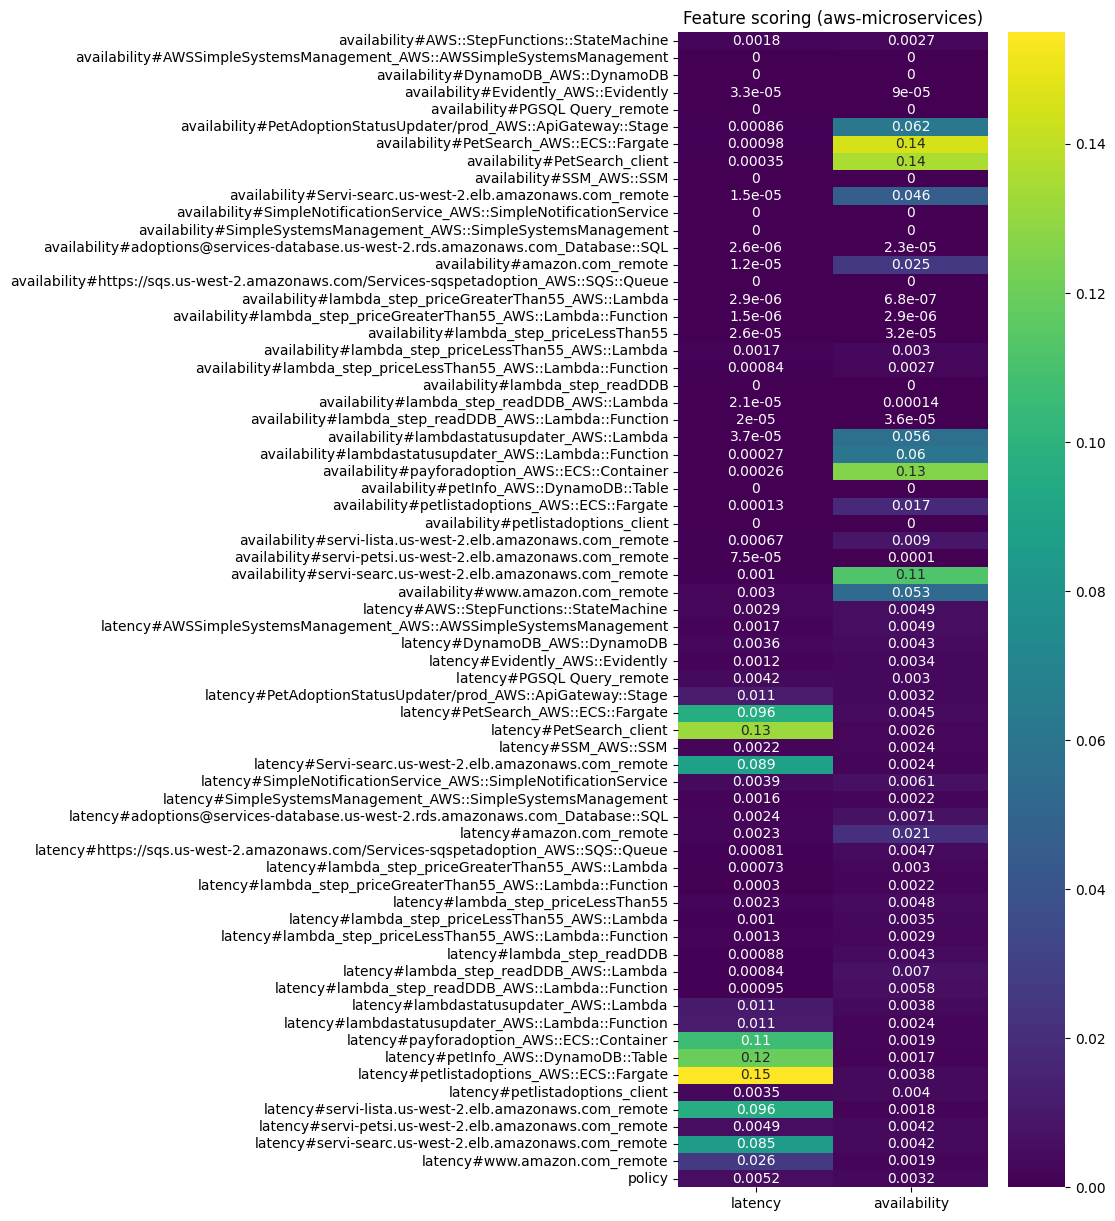

,latency,availability
0,,
availability#AWS::StepFunctions::StateMachine,0.001839,0.002744
availability#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,0.000000,0.000000
availability#DynamoDB_AWS::DynamoDB,0.000000,0.000000
availability#Evidently_AWS::Evidently,0.000033,0.000090
availability#PGSQL Query_remote,0.000000,0.000000
...,...,...
latency#servi-lista.us-west-2.elb.amazonaws.com_remote,0.096375,0.001790
latency#servi-petsi.us-west-2.elb.amazonaws.com_remote,0.004878,0.004214
latency#servi-searc.us-west-2.elb.amazonaws.com_remote,0.085267,0.004182


In [12]:
policy_size = (5,15)
# filter_params = PipesAndFilters.COMMON_PARAMETERS
fs = show_feature_scores(my_space, title='Feature scoring (aws-microservices)', size=policy_size) #, parameters=filter_params) #, filename=None)  
fs

In [13]:
kp = list(fs.query('(latency > 0.05) or (availability > 0.05)').index)
fs.query('(latency > 0.05) or (availability > 0.05)')
# kp = list(fs.query('(availability > 0.05)').index)
# fs.query('(availability > 0.05)')

,latency,availability
0,,
availability#PetAdoptionStatusUpdater/prod_AWS::ApiGateway::Stage,0.000856,0.062222
availability#PetSearch_AWS::ECS::Fargate,0.000981,0.144840
availability#PetSearch_client,0.000352,0.135498
availability#lambdastatusupdater_AWS::Lambda,0.000037,0.055923
availability#lambdastatusupdater_AWS::Lambda::Function,0.000271,0.060383
availability#payforadoption_AWS::ECS::Container,0.000265,0.125953
availability#servi-searc.us-west-2.elb.amazonaws.com_remote,0.001004,0.112495
availability#www.amazon.com_remote,0.003009,0.052919
latency#PetSearch_AWS::ECS::Fargate,0.095863,0.004534


In [14]:
my_policies = my_space.get_configurations()
my_policies

['high_traffic', 'low_traffic', 'temporal1', 'temporal2']

Absolute ranges: [(0.08, 1.018), (91, 100.0)]
latency [-0.020000000000000004, 0.35933333333333334, 0.7386666666666667, 1.118]
availability [90.9, 93.96666666666667, 97.03333333333333, 100.1]


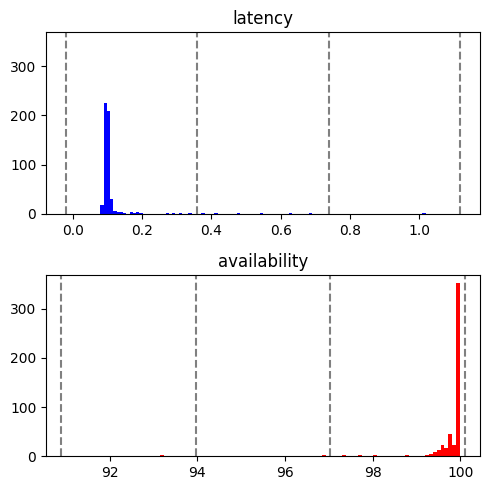

In [15]:
MIN_LATENCY, MAX_LATENCY = (0.08, 1.018)
MIN_AVAILABIITY,  MAX_AVAILABILITY = (91, 100.0)

MIN_MAX_RANGES = [(MIN_LATENCY, MAX_LATENCY), (MIN_AVAILABIITY, MAX_AVAILABILITY)]
print('Absolute ranges:', MIN_MAX_RANGES)

_ = show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

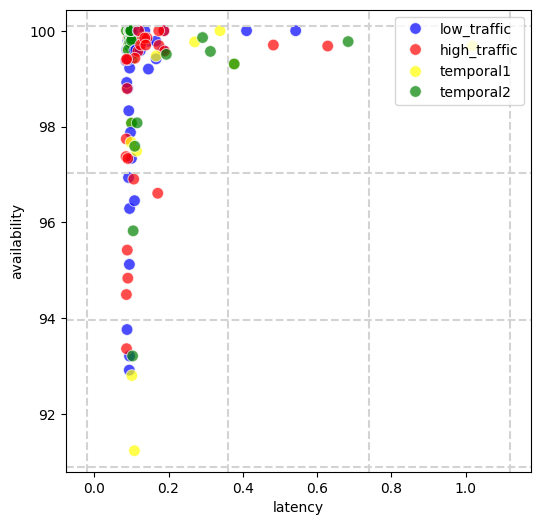

In [16]:
df = outcomes_df.copy()
df['decision'] = experiments_df['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7,color_key=color_key, qualities=['latency', 'availability'])

In [17]:
print("Configurations:", my_space.get_configurations())

Configurations: ['high_traffic', 'low_traffic', 'temporal1', 'temporal2']


Experiments for policy temporal1 : 173
latency [-0.020000000000000004, 0.35933333333333334, 0.7386666666666667, 1.118]
availability [90.9, 93.96666666666667, 97.03333333333333, 100.1]


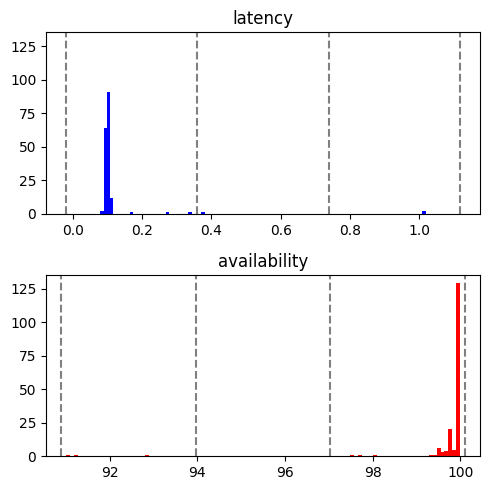

{'latency': [-0.020000000000000004,
  0.35933333333333334,
  0.7386666666666667,
  1.118],
 'availability': [90.9, 93.96666666666667, 97.03333333333333, 100.1]}

In [18]:
show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5), policy='temporal1')

Experiments for policy low_traffic : 85
latency [-0.020000000000000004, 0.35933333333333334, 0.7386666666666667, 1.118]
availability [90.9, 93.96666666666667, 97.03333333333333, 100.1]


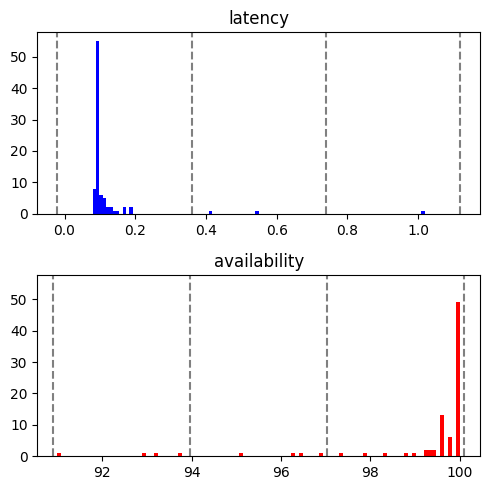

{'latency': [-0.020000000000000004,
  0.35933333333333334,
  0.7386666666666667,
  1.118],
 'availability': [90.9, 93.96666666666667, 97.03333333333333, 100.1]}

In [19]:
show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5), policy='low_traffic')

In [20]:
# Count feasible tradeoffs in the dataset
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)
my_space.available_tradeoffs_

Experiments: (516, 69)


Counter({'fast,high': 491,
         'fast,average': 10,
         'average,high': 7,
         'fast,low': 7,
         'slow,high': 1})

In [21]:
# Split dataset for ML analysis (train/test sets). Also outliers removal
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.4, remove_outliers=3)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(516, 71) 516
Removing outliers ... 3
Instances to remove (outliers): {513, 515, 134, 299, 450, 452, 455, 465, 466, 467, 468, 472, 475, 478, 484, 487, 489, 490, 500, 503, 506, 507, 508, 510}
Instances to remove (not enough tradeoffs): {513, 515, 134, 299, 450, 452, 455, 465, 466, 467, 468, 472, 475, 478, 484, 487, 489, 490, 500, 503, 506, 507, 508, 510}
{'fast,high', 'fast,average'}
(492, 71) 492
(295, 71) (295, 2) (197, 71) (197, 2)


In [22]:
X_train[['latency', 'availability']].describe()

,latency,availability
count,295.000000,295.000000
mean,0.102962,99.842308
std,0.020186,0.455591
min,0.086166,96.902655
25%,0.096372,99.850957
50%,0.099070,100.000000
75%,0.102137,100.000000
max,0.291723,100.000000


In [23]:
X_test[['latency', 'availability']].describe()

,latency,availability
count,197.000000,197.000000
mean,0.101507,99.830054
std,0.013889,0.441244
min,0.085174,96.607670
25%,0.095912,99.802761
50%,0.099023,100.000000
75%,0.102184,100.000000
max,0.187529,100.000000


Absolute ranges: [(0.08, 0.3), (95, 100.0)]
latency [-0.020000000000000004, 0.12000000000000001, 0.26, 0.4]
availability [94.9, 96.63333333333334, 98.36666666666666, 100.1]


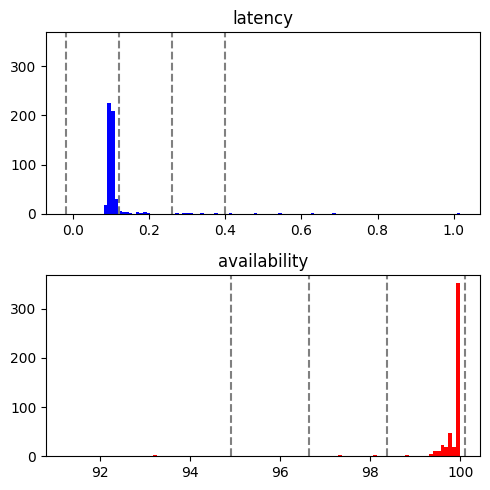

{'latency': [-0.020000000000000004, 0.12000000000000001, 0.26, 0.4],
 'availability': [94.9, 96.63333333333334, 98.36666666666666, 100.1]}

In [24]:
MIN_LATENCY, MAX_LATENCY = (0.08, 0.3)
MIN_AVAILABIITY,  MAX_AVAILABILITY = (95, 100.0)
MIN_MAX_RANGES = [(MIN_LATENCY, MAX_LATENCY), (MIN_AVAILABIITY, MAX_AVAILABILITY)]
print('Absolute ranges:', MIN_MAX_RANGES)

show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

In [25]:
df_concat = pd.concat([X_train, X_test], axis=0)
df_concat.reset_index(drop=True, inplace=True)
df_concat[['latency', 'availability']].describe()

,latency,availability
count,492.000000,492.000000
mean,0.102379,99.837402
std,0.017930,0.449489
min,0.085174,96.607670
25%,0.096217,99.820270
50%,0.099037,100.000000
75%,0.102184,100.000000
max,0.291723,100.000000


Experiments: (516, 69)
Counter({'fast,high': 455, 'average,high': 20, 'fast,average': 14, 'slow,high': 2, 'average,low': 1})


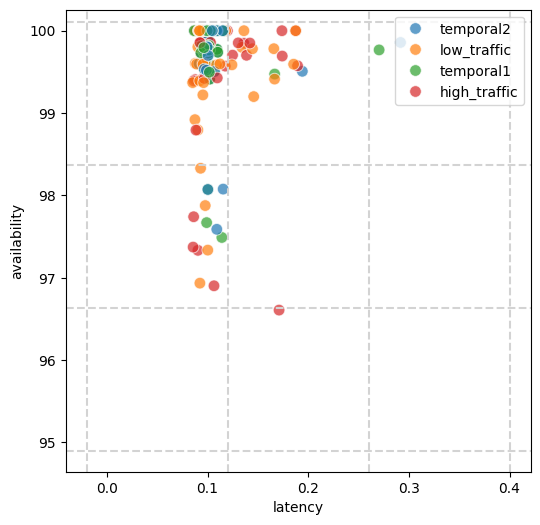

In [26]:
my_space.import_dataset(df_concat, df_concat[['latency', 'availability']])
 
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)
print(my_space.available_tradeoffs_)

df = df_concat[['latency', 'availability','policy']].copy()
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7, qualities=['latency', 'availability'])

Computing robustness for all configurations...


100%|██████████| 4/4 [00:00<00:00, 27.38it/s]


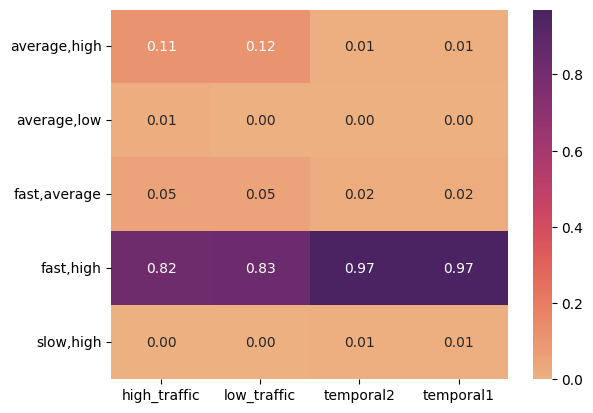

,high_traffic,low_traffic,temporal2,temporal1
"average,high",0.113924,0.116883,0.005952,0.005952
"average,low",0.012658,0.000000,0.000000,0.000000
"fast,average",0.050633,0.051948,0.017857,0.017857
"fast,high",0.822785,0.831169,0.970238,0.970238
"slow,high",0.000000,0.000000,0.005952,0.005952


In [27]:
print("Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
# df.to_csv('./pipesandfilters_robustness_matrix.csv')

sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')
plt.show()
df

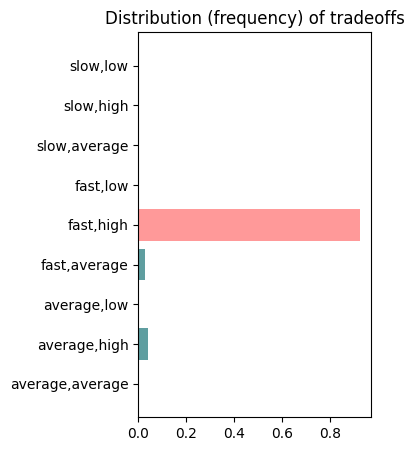

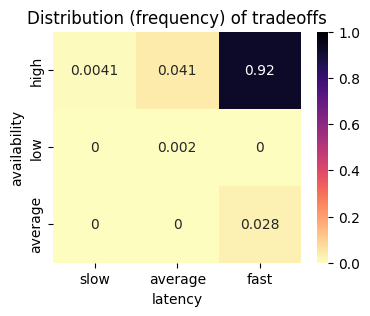

In [28]:
show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

temporal1 Counter({'fast,high': 163, 'fast,average': 3, 'slow,high': 1, 'average,high': 1})
Instances for configuration: (168, 2)


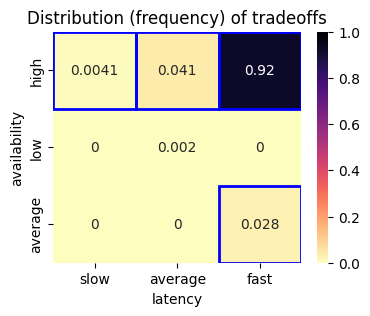

In [29]:
config = 'temporal1'
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

temporal2 Counter({'fast,high': 163, 'fast,average': 3, 'average,high': 1, 'slow,high': 1})
Instances for configuration: (168, 2)


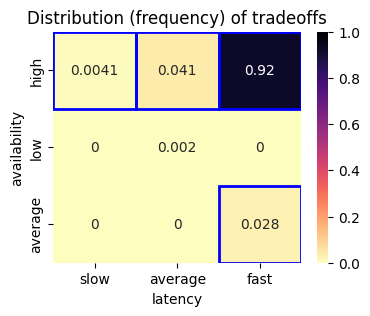

In [30]:
config = 'temporal2'
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

low_traffic Counter({'fast,high': 64, 'average,high': 9, 'fast,average': 4})
Instances for configuration: (77, 2)


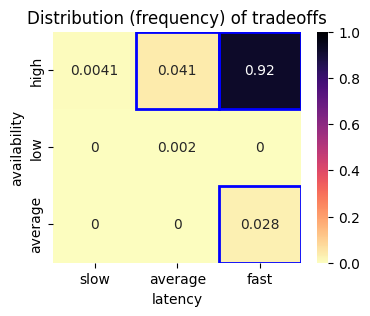

In [31]:
config = 'low_traffic'
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

high_traffic Counter({'fast,high': 65, 'average,high': 9, 'fast,average': 4, 'average,low': 1})
Instances for configuration: (79, 2)


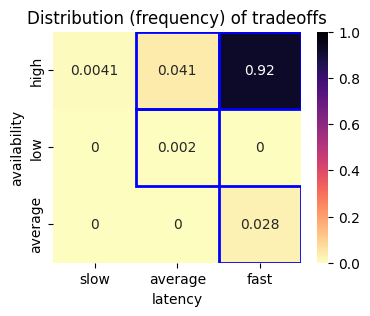

In [32]:
config = 'high_traffic'
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [33]:
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,latency,-0.014826,0.120690,fast
1,latency,0.120690,0.256207,average
2,latency,0.256207,0.391723,slow
3,availability,96.507670,97.705113,low
4,availability,97.705113,98.902557,average
5,availability,98.902557,100.100000,high


In [34]:
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,latency,-0.014826,0.120690,fast
1,latency,0.120690,0.256207,average
2,latency,0.256207,0.391723,slow
3,availability,96.507670,97.705113,low
4,availability,97.705113,98.902557,average
5,availability,98.902557,100.100000,high


  Computing robustness for all configurations (train set)...
Counter({'fast,high': 271, 'average,high': 12, 'fast,average': 10, 'slow,high': 2})


100%|██████████| 4/4 [00:00<00:00, 28.50it/s]


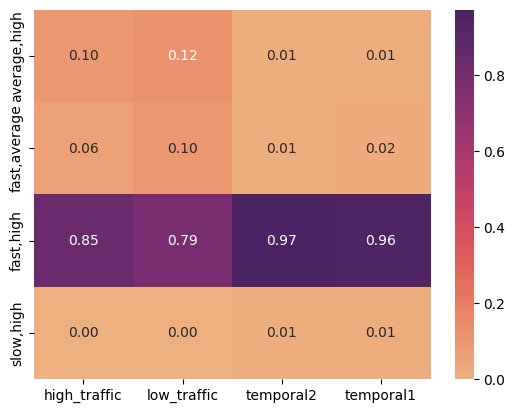

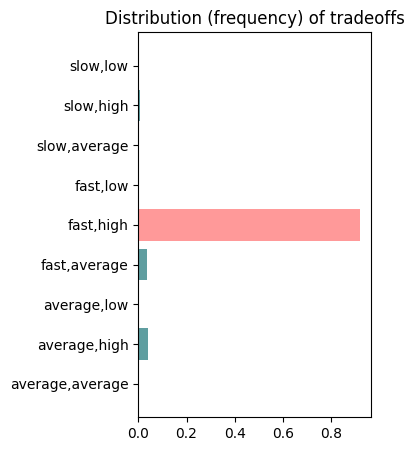

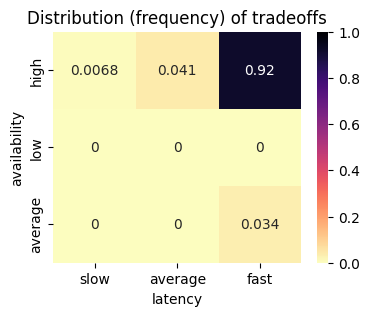

,high_traffic,low_traffic,temporal2,temporal1
"average,high",0.096154,0.119048,0.009524,0.010417
"fast,average",0.057692,0.095238,0.009524,0.020833
"fast,high",0.846154,0.785714,0.971429,0.958333
"slow,high",0.000000,0.000000,0.009524,0.010417


In [35]:
# Work first with the train set

# my_space.import_dataset(X_test, y_test)
my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)

print("  Computing robustness for all configurations (train set)...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

df

  Computing robustness for all configurations (test set)...
Counter({'fast,high': 184, 'average,high': 8, 'fast,average': 4, 'average,low': 1})


100%|██████████| 4/4 [00:00<00:00, 19.38it/s]


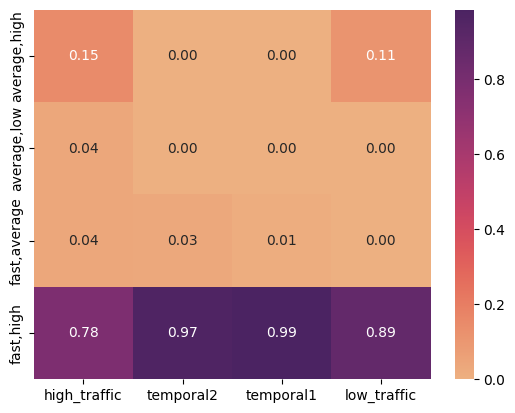

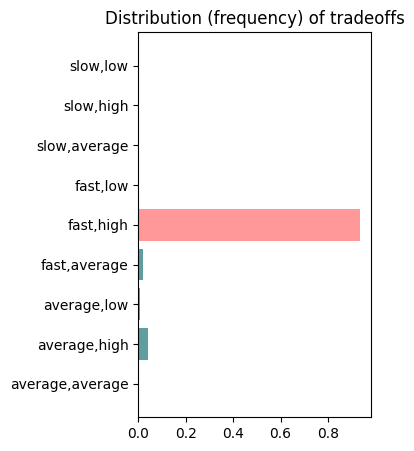

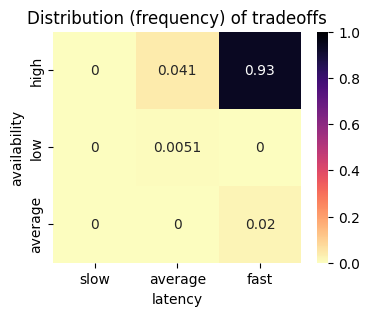

,high_traffic,temporal2,temporal1,low_traffic
"average,high",0.148148,0.000000,0.000000,0.114286
"average,low",0.037037,0.000000,0.000000,0.000000
"fast,average",0.037037,0.031746,0.013889,0.000000
"fast,high",0.777778,0.968254,0.986111,0.885714


In [45]:
# Work first with the test set

my_space.import_dataset(X_test, y_test)
# my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)

print("  Computing robustness for all configurations (test set)...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

df

In [36]:
# Run PRIM for each tradeoff using the train set, and then evaluate the robustness achieved on the test set
warnings.filterwarnings('ignore')
# my_space.import_dataset(X_train, y_train)

# kp = ['N_A', 'N_B', 'r_gw', 'r_A_s1', 'r_B_s2', 'r_B_s3']
# kp = ['N_A', 'N_B', 'S_gw'] #, 'r_A_s1', 'r_B_s2', 'r_B_s3']
my_policies = my_space.get_configurations()
qa_labels = list(my_space.available_tradeoffs_.keys())
qa_labels.sort()
property_ranges_dict = dict()
for qa_label in qa_labels:
    # TODO: Also loop over the different policies (configurations)?
    # for policy in my_policies:
        policy = None
        my_space.import_dataset(X_train, y_train)
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        n = my_space.available_tradeoffs_[qa_label]
        
        if n > 0:
            print()
            print("Checking (with PRIM) ----")
            property_to_check = my_space.get_property_box(qa_label)
            print("  Property: ", qa_label, property_to_check)
            print("  Policy: ", policy)

            try:
                box1, prange, prim_model = my_space.run_prim(property_to_check, policy=policy,
                                                         threshold=0.8, method='rhodium', # 'emaw' 'rhodium'
                                                         key_parameters=kp, verbose=False)
                # print(box1)
                print("  New ranges:",  prange)
                if len(prange) > 0:
                    property_ranges_dict[qa_label] = prange
            except Exception:
                print("EXCEPTION triggered!") 
                pass

            my_space.import_dataset(X_test, y_test)
            my_space.adjust_parameters(prange)
            _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
            print("  Experiments:", my_space.experiments_df_.shape)
            print(my_space.compute_robustness(policy, qa_label))

            print("  Computing robustness for all configurations (test set) ...")
            df = my_space.compute_robustness_matrix()
            print(df)
            # plt.show()

my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)


Checking (with PRIM) ----
  Property:  average,high {'latency': (0.12000000000000001, 0.26), 'availability': (98.36666666666666, 100.1)}
  Policy:  None
  New ranges: {'availability#payforadoption_AWS::ECS::Container': {'min': 96.07843137254902, 'max': 100.0}, 'latency#PetSearch_AWS::ECS::Fargate': {'min': 0.0060082677596666, 'max': 0.0720621039896987}, 'latency#PetSearch_client': {'min': 0.0034534721777009997, 'max': 0.00729699134696695}, 'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.008510823216704249, 'max': 0.03454661369}, 'latency#payforadoption_AWS::ECS::Container': {'min': 0.1678710987342982, 'max': 0.8253752635703936}, 'latency#petInfo_AWS::DynamoDB::Table': {'min': 0.014356821163151751, 'max': 0.0221902097885309}, 'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.0215026794015426, 'max': 0.0290069514539759}, 'latency#servi-lista.us-west-2.elb.amazonaws.com_remote': {'min': 0.0326713395363855, 'max': 0.04556456157555555}, 'latency#servi-searc.us-wes

100%|██████████| 4/4 [00:00<00:00, 88.15it/s]


              high_traffic  low_traffic  temporal2  temporal1
average,high      0.666667          0.2        0.0   0.000000
fast,average      0.000000          0.0        0.0   0.333333
fast,high         0.333333          0.8        1.0   0.666667

Checking (with PRIM) ----
  Property:  fast,average {'latency': (-0.020000000000000004, 0.12000000000000001), 'availability': (96.63333333333334, 98.36666666666666)}
  Policy:  None
  New ranges: {}
  Experiments: (197, 69)
(0.0, 'fast,average')
  Computing robustness for all configurations (test set) ...


100%|██████████| 4/4 [00:00<00:00, 30.61it/s]


              high_traffic  temporal2  temporal1  low_traffic
average,high      0.148148   0.000000   0.000000     0.114286
average,low       0.037037   0.000000   0.000000     0.000000
fast,average      0.037037   0.031746   0.013889     0.000000
fast,high         0.777778   0.968254   0.986111     0.885714

Checking (with PRIM) ----
  Property:  fast,high {'latency': (-0.020000000000000004, 0.12000000000000001), 'availability': (98.36666666666666, 100.1)}
  Policy:  None
  New ranges: {'availability#PetSearch_AWS::ECS::Fargate': {'min': 100.0, 'max': 100.0}, 'availability#payforadoption_AWS::ECS::Container': {'min': 100.0, 'max': 100.0}, 'latency#payforadoption_AWS::ECS::Container': {'min': 0.1678710987342982, 'max': 0.22345520158524418}, 'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.0170746392516641, 'max': 0.02522493241511955}, 'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.009631023954673, 'max': 0.11808491099444404}}
  Experiments: (173, 69)
(0.0, '

100%|██████████| 4/4 [00:00<00:00, 118.20it/s]

              high_traffic  low_traffic  temporal1  temporal2
average,high      0.055556          0.0   0.000000   0.000000
fast,average      0.000000          0.0   0.014493   0.033898
fast,high         0.944444          1.0   0.985507   0.966102

Checking (with PRIM) ----
  Property:  slow,high {'latency': (0.26, 0.4), 'availability': (98.36666666666666, 100.1)}
  Policy:  None


  New ranges: {'latency#PetSearch_AWS::ECS::Fargate': {'min': 0.0064153085596437, 'max': 0.00743237219267955}, 'latency#PetSearch_client': {'min': 0.0026098770244438498, 'max': 0.0242778158147104}, 'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.0076395659318012, 'max': 0.0109624226163611}, 'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.02148783115208825, 'max': 0.0244912025699165}, 'latency#servi-lista.us-west-2.elb.amazonaws.com_remote': {'min': 0.0361283679756904, 'max': 0.0484786454288235}, 'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.01099011530943585, 'max': 0.2448973717331549}}
  Experiments: (12, 69)
(0.0, 'slow,high')
  Computing robustness for all configurations (test set) ...


100%|██████████| 3/3 [00:00<00:00, 163.12it/s]

              low_traffic  temporal2  temporal1
average,high        0.125        0.0        0.0
fast,high           0.875        1.0        1.0


In [37]:
print("PRIM Ranges:", len(property_ranges_dict) )
property_ranges_dict

PRIM Ranges: 3


{'average,high': {'availability#payforadoption_AWS::ECS::Container': {'min': 96.07843137254902,
   'max': 100.0},
  'latency#PetSearch_AWS::ECS::Fargate': {'min': 0.0060082677596666,
   'max': 0.0720621039896987},
  'latency#PetSearch_client': {'min': 0.0034534721777009997,
   'max': 0.00729699134696695},
  'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.008510823216704249,
   'max': 0.03454661369},
  'latency#payforadoption_AWS::ECS::Container': {'min': 0.1678710987342982,
   'max': 0.8253752635703936},
  'latency#petInfo_AWS::DynamoDB::Table': {'min': 0.014356821163151751,
   'max': 0.0221902097885309},
  'latency#petlistadoptions_AWS::ECS::Fargate': {'min': 0.0215026794015426,
   'max': 0.0290069514539759},
  'latency#servi-lista.us-west-2.elb.amazonaws.com_remote': {'min': 0.0326713395363855,
   'max': 0.04556456157555555},
  'latency#servi-searc.us-west-2.elb.amazonaws.com_remote': {'min': 0.011964308154386,
   'max': 0.2448973717331549}},
 'fast,high': {'avail

In [38]:
policy = None
my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
# n = my_space.available_tradeoffs_[qa_label]

# kp = ['N_A', 'N_B', 'r_gw', 'r_A_s1', 'r_B_s2', 'r_B_s3']
# kp = ['N_A', 'N_B', 'S_gw'] #, 's_A_s1', 's_B_s2', 's_B_s3']        
print("Checking (with CART) ---- all properties")
print("  Policy: ", policy)

# TODO: This is not considering a specific policy, but all of them! Should we consider/loop for a specific policy?
triple_rules, ranges, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())
print("  New ranges:")
for r in ranges.keys():
    print("\t", r, ranges[r])
print("Rules:")
for t in triple_rules:
    print(t)

print()
print("Testing ---- ")
qa_labels = list(my_space.available_tradeoffs_.keys())
qa_labels.sort()
property_ranges_dict = dict()
for qa_label in ranges: # qa_labels:
    print()
    property_to_check = my_space.get_property_box(qa_label)
    prange = ranges[qa_label]
    print("  Property: ", qa_label, property_to_check)
    print("  Range:",  prange)
    
    my_space.import_dataset(X_test, y_test)
    my_space.adjust_parameters(prange)
    n = my_space.available_tradeoffs_[qa_label]
    if n > 0:
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        print("  Experiments:", my_space.experiments_df_.shape)
        if my_space.experiments_df_.shape[0] > 0:
            print(my_space.compute_robustness(policy, qa_label))
            if len(prange) > 0:
                property_ranges_dict[qa_label] = prange

        print("  Computing robustness for all configurations (test set) ...")
        df = my_space.compute_robustness_matrix()
        print(df)
        # plt.show()
    else:
        print("  No experiments in this range")

my_space.import_dataset(X_train, y_train)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)

Checking (with CART) ---- all properties
  Policy:  None
(295, 16) Index(['availability#PetAdoptionStatusUpdater/prod_AWS::ApiGateway::Stage',
       'availability#PetSearch_AWS::ECS::Fargate',
       'availability#PetSearch_client',
       'availability#lambdastatusupdater_AWS::Lambda',
       'availability#lambdastatusupdater_AWS::Lambda::Function',
       'availability#payforadoption_AWS::ECS::Container',
       'availability#servi-searc.us-west-2.elb.amazonaws.com_remote',
       'availability#www.amazon.com_remote',
       'latency#PetSearch_AWS::ECS::Fargate', 'latency#PetSearch_client',
       'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote',
       'latency#payforadoption_AWS::ECS::Container',
       'latency#petInfo_AWS::DynamoDB::Table',
       'latency#petlistadoptions_AWS::ECS::Fargate',
       'latency#servi-lista.us-west-2.elb.amazonaws.com_remote',
       'latency#servi-searc.us-west-2.elb.amazonaws.com_remote'],
      dtype='object')
Running CART ... 0.006779661

100%|██████████| 4/4 [00:00<00:00, 43.41it/s]


              high_traffic  temporal2  temporal1  low_traffic
average,high      0.045455   0.000000   0.000000     0.033333
fast,average      0.045455   0.031746   0.013889     0.000000
fast,high         0.909091   0.968254   0.986111     0.966667

  Property:  average,high {'latency': (0.12000000000000001, 0.26), 'availability': (98.36666666666666, 100.1)}
  Range: {'latency#payforadoption_AWS::ECS::Container': {'min': 0.369000001, 'max': 0.825}}
  No experiments in this range

  Property:  fast,average {'latency': (-0.020000000000000004, 0.12000000000000001), 'availability': (96.63333333333334, 98.36666666666666)}
  Range: {'latency#PetSearch_AWS::ECS::Fargate': {'min': 0, 'max': 0.009}, 'latency#payforadoption_AWS::ECS::Container': {'min': 0, 'max': 0.369}, 'availability#payforadoption_AWS::ECS::Container': {'min': 0, 'max': 96.078}}
  Experiments: (1, 69)
(0.0, 'fast,average')
  Computing robustness for all configurations (test set) ...


100%|██████████| 1/1 [00:00<00:00, 245.04it/s]

             high_traffic
average,low           1.0

  Property:  slow,high {'latency': (0.26, 0.4), 'availability': (98.36666666666666, 100.1)}
  Range: {'latency#payforadoption_AWS::ECS::Container': {'min': 0.8250000009999999, 'max': inf}}
  No experiments in this range


In [39]:
print("CART Ranges:", len(property_ranges_dict) )
property_ranges_dict

CART Ranges: 2


{'fast,high': {'latency#PetSearch_AWS::ECS::Fargate': {'min': 0, 'max': 0.009},
  'latency#payforadoption_AWS::ECS::Container': {'min': 0, 'max': 0.369},
  'availability#payforadoption_AWS::ECS::Container': {'min': 96.078000001,
   'max': inf}},
 'fast,average': {'latency#PetSearch_AWS::ECS::Fargate': {'min': 0,
   'max': 0.009},
  'latency#payforadoption_AWS::ECS::Container': {'min': 0, 'max': 0.369},
  'availability#payforadoption_AWS::ECS::Container': {'min': 0,
   'max': 96.078}}}

Checking (with CART) ---- all properties
  Policy:  None
(295, 16) Index(['availability#PetAdoptionStatusUpdater/prod_AWS::ApiGateway::Stage',
       'availability#PetSearch_AWS::ECS::Fargate',
       'availability#PetSearch_client',
       'availability#lambdastatusupdater_AWS::Lambda',
       'availability#lambdastatusupdater_AWS::Lambda::Function',
       'availability#payforadoption_AWS::ECS::Container',
       'availability#servi-searc.us-west-2.elb.amazonaws.com_remote',
       'availability#www.amazon.com_remote',
       'latency#PetSearch_AWS::ECS::Fargate', 'latency#PetSearch_client',
       'latency#Servi-searc.us-west-2.elb.amazonaws.com_remote',
       'latency#payforadoption_AWS::ECS::Container',
       'latency#petInfo_AWS::DynamoDB::Table',
       'latency#petlistadoptions_AWS::ECS::Fargate',
       'latency#servi-lista.us-west-2.elb.amazonaws.com_remote',
       'latency#servi-searc.us-west-2.elb.amazonaws.com_remote'],
      dtype='object')
Running CART ... 0.006779661

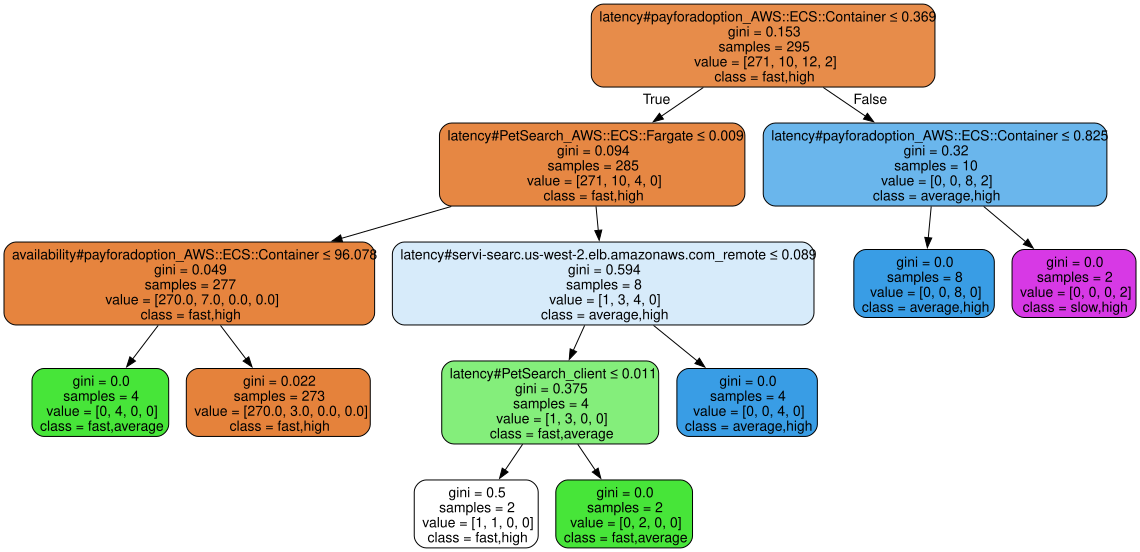

In [40]:
policy = None
my_space.import_dataset(X_train, y_train)
# my_space.import_dataset(X_test, y_test)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
# n = my_space.available_tradeoffs_[qa_label]

# kp = ['N_A', 'N_B', 'r_gw', 'r_A_s1', 'r_B_s2', 'r_B_s3']
# kp = ['N_A', 'N_B', 'S_gw'] #, 's_A_s1', 's_B_s2', 's_B_s3']        
print("Checking (with CART) ---- all properties")
print("  Policy: ", policy)

triple_rules, ranges, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())

# class_names =  list(set(my_space._get_cluster_labels()))
class_names = [*Counter(my_space._get_cluster_labels())] # Remove duplicates but keep the order
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

print(tree.export_text(clf))
# pprint(tree.export_text(prunedTree))

graph

In [41]:
my_space.import_dataset(X_test, y_test)
# my_space.import_dataset(X_train, y_train)
print("  Computing robustness for all configurations...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
df

  Computing robustness for all configurations...
Counter({'fast,high': 196, 'fast,average': 1})


100%|██████████| 4/4 [00:00<00:00, 123.50it/s]


,high_traffic,temporal2,temporal1,low_traffic
"fast,average",0.037037,0.0,0.0,0.0
"fast,high",0.962963,1.0,1.0,1.0


In [42]:
my_space.import_dataset(X_test, y_test)

In [43]:
my_space.experiments_df_

,scenario,latency#SimpleSystemsManagement_AWS::SimpleSystemsManagement,latency#petlistadoptions_AWS::ECS::Fargate,latency#lambda_step_priceLessThan55,latency#petlistadoptions_client,latency#lambda_step_priceLessThan55_AWS::Lambda,latency#Servi-searc.us-west-2.elb.amazonaws.com_remote,latency#lambda_step_priceLessThan55_AWS::Lambda::Function,latency#https://sqs.us-west-2.amazonaws.com/Services-sqspetadoption_AWS::SQS::Queue,latency#PetSearch_AWS::ECS::Fargate,...,availability#PGSQL Query_remote,availability#payforadoption_AWS::ECS::Container,availability#SSM_AWS::SSM,availability#AWS::StepFunctions::StateMachine,availability#Evidently_AWS::Evidently,availability#PetSearch_client,availability#AWSSimpleSystemsManagement_AWS::AWSSimpleSystemsManagement,availability#servi-lista.us-west-2.elb.amazonaws.com_remote,model,policy
0,0,0.015375,0.025634,1.724654,0.000043,1.830571,0.008421,2.075897,0.009598,0.005731,...,100.0,100.0,100.0,69.565217,100.0,100.0,100.0,100.000000,aws_microservices,temporal2
1,0,0.015867,0.024540,0.376040,0.000057,0.449000,0.008771,0.466028,0.006867,0.005952,...,100.0,100.0,100.0,22.580645,0.0,100.0,100.0,100.000000,aws_microservices,high_traffic
2,0,0.015790,0.022195,1.492093,0.000046,1.620200,0.007767,1.630007,0.009529,0.006244,...,100.0,100.0,100.0,68.750000,100.0,100.0,100.0,100.000000,aws_microservices,temporal1
3,10,0.016053,0.023106,2.364174,0.000061,2.477000,0.009691,2.480247,0.007535,0.006566,...,100.0,100.0,100.0,37.500000,100.0,100.0,100.0,93.548387,aws_microservices,low_traffic
4,0,0.016169,0.024101,0.260862,0.000045,3.560000,0.010224,3.004793,0.011466,0.006140,...,100.0,100.0,100.0,66.666667,100.0,100.0,100.0,100.000000,aws_microservices,low_traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,0,0.015665,0.018088,2.333749,0.000043,2.465000,0.007699,2.477432,0.011344,0.006391,...,100.0,100.0,100.0,54.545455,100.0,100.0,100.0,100.000000,aws_microservices,temporal1
193,0,0.016361,0.022174,0.260862,0.000046,4.934500,0.006920,3.007850,0.007535,0.005801,...,100.0,100.0,100.0,50.000000,100.0,100.0,100.0,100.000000,aws_microservices,low_traffic
194,0,0.015080,0.019612,1.982440,0.000043,3.921286,0.008595,2.768032,0.009480,0.006679,...,100.0,100.0,100.0,42.105263,100.0,100.0,100.0,100.000000,aws_microservices,temporal1
195,0,0.016809,0.019408,0.799855,0.000044,0.898000,0.008430,0.902227,0.010001,0.006186,...,100.0,100.0,100.0,77.777778,100.0,100.0,100.0,100.000000,aws_microservices,temporal2


In [44]:
print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

print("  Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
df

Reducing range for tradeoff: slow,high {'latency': (0.26, 0.4), 'availability': (98.36666666666666, 100.1)}
New ranges: {'latency#payforadoption_AWS::ECS::Container': {'min': 0.8250000009999999, 'max': inf}}
Experiments: (0, 69)


ZeroDivisionError: float division by zero

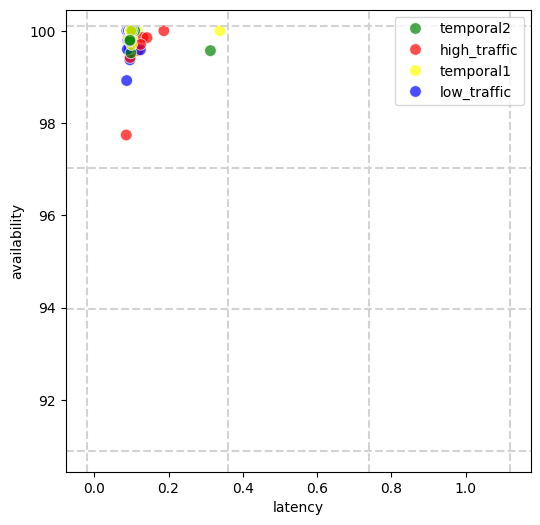

In [ ]:
df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7, color_key=color_key, qualities=['latency', 'availability'])

In [ ]:
print("Computing robustness for all configurations...")
main_dict = dict()
for exp in tqdm(my_space.get_configurations()):
    print(exp)
    main_dict[str(exp)] = dict()
    for qa in my_space.available_tradeoffs_.keys():
        main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
df

Computing robustness for all configurations...


100%|██████████| 4/4 [00:00<00:00, 170.31it/s]

temporal1
high_traffic
temporal2
low_traffic


,temporal1,high_traffic,temporal2,low_traffic
"fast,high",1.0,1.0,1.0,1.0
